In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<ipython-input-51-05b6bf6ec2f1>:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(10,10,'Hubble Constant={:.2f}'.format(float(model_1.coef_)))


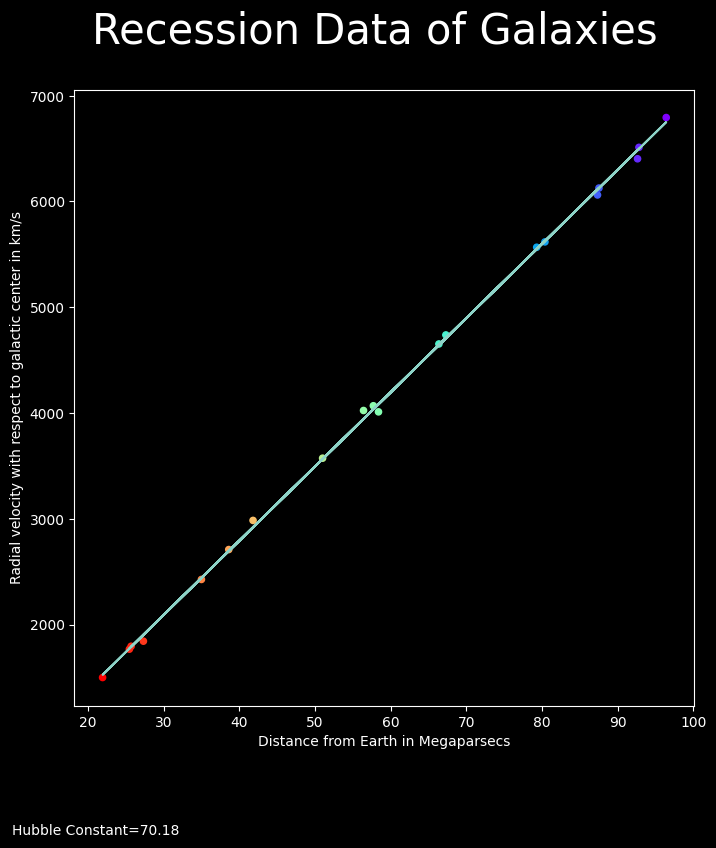

<ipython-input-51-05b6bf6ec2f1>:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(30,10,'Hubble Constant={:.2f}'.format(float(model_1_filtered_1.coef_)))


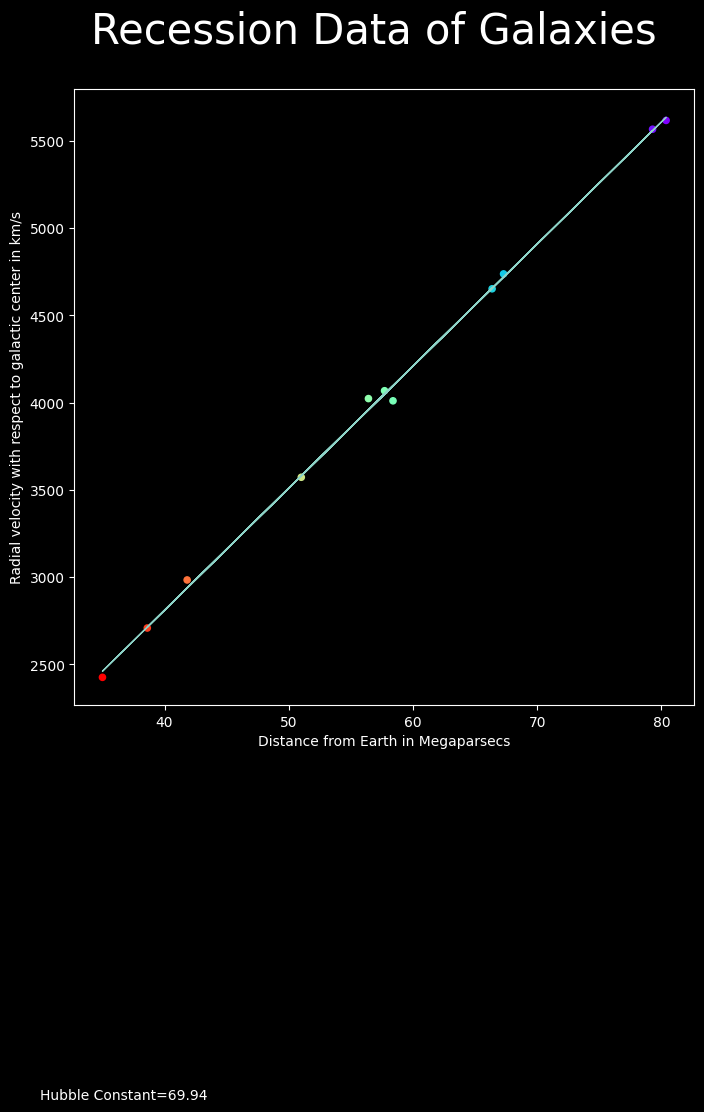

70.179968368159
69.93957977728282


In [ ]:
#defining path for data
data_1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/data_1.xlsx - Sheet1.csv', delimiter=',', header=None, names=['Distance (Mpc)', 'Velocity (km/s)'])

data_1['Distance (Mpc)'] = pd.to_numeric(data_1['Distance (Mpc)'], errors='coerce')
data_1['Velocity (km/s)'] = pd.to_numeric(data_1['Velocity (km/s)'], errors='coerce')
data_1 = data_1.dropna(subset=['Distance (Mpc)','Velocity (km/s)'])

#assigning variables x and y for columns of data
x_1 = data_1['Distance (Mpc)']
y_1 = data_1['Velocity (km/s)']

#using parameters to take care of outliers
x_avg_1 = x_1.mean()
x_std_1 = x_1.std()
y_avg_1 = y_1.mean()
y_std_1 = y_1.std()

#lists to store non-outliers
x_1_filtered = []
y_1_filtered = []

#processing outliers
length_1 = len(x_1)
for i in range(length_1):
    if (x_1.iloc[i] <= x_avg_1 + x_std_1 and x_1.iloc[i] >= x_avg_1 - x_std_1 and
        y_1.iloc[i] <= y_avg_1 + y_std_1 and y_1.iloc[i] >= y_avg_1 - y_std_1):
        x_1_filtered.append(x_1.iloc[i])
        y_1_filtered.append(y_1.iloc[i])

#fitting the model with outliers for dataset 1
model_1 = LinearRegression()
model_1.fit(np.array(x_1).reshape(-1, 1), np.array(y_1))
y_predicted_1 = model_1.coef_ * x_1 + model_1.intercept_

#plotting data with outliers
plt.style.use("dark_background")
plt.figure(figsize = (8,8))
plt.scatter(x_1, y_1, c = x_1, cmap = 'rainbow_r', s=20)
plt.plot(x_1, y_predicted_1)
plt.suptitle("Recession Data of Galaxies", fontsize = 30)
plt.xlabel('Distance from Earth in Megaparsecs')
plt.ylabel('Radial velocity with respect to galactic center in km/s')
plt.text(10,10,'Hubble Constant={:.2f}'.format(float(model_1.coef_)))
plt.show()

#fitting the models without outliers for dataset 1
model_1_filtered_1 = LinearRegression()
model_1_filtered_1.fit(np.array(x_1_filtered).reshape(-1, 1), np.array(y_1_filtered))
y_predicted_filtered_1 = model_1_filtered_1.coef_ * x_1_filtered + model_1_filtered_1.intercept_

#plotting data without outliers
plt.style.use("dark_background")
plt.figure(figsize = (8,8))
plt.scatter(x_1_filtered, y_1_filtered, c = x_1_filtered, cmap = 'rainbow_r', s=20)
plt.plot(x_1_filtered, y_predicted_filtered_1, linewidth = 1)
plt.suptitle("Recession Data of Galaxies", fontsize = 30)
plt.xlabel('Distance from Earth in Megaparsecs')
plt.ylabel('Radial velocity with respect to galactic center in km/s')
plt.text(30,10,'Hubble Constant={:.2f}'.format(float(model_1_filtered_1.coef_)))
plt.show()



hubble_1 = model_1.coef_[0]
hubble_1_non = model_1_filtered_1.coef_[0]
print(hubble_1)
print(hubble_1_non)